# Week 6 · Notebook 2 — Differential Evolution and CMA-ES

**Goals**
- Implement differential evolution (Storn & Price 1997) in three strategies — DE/rand/1/bin, DE/best/1/bin and
  DE/current-to-pbest/1 with JADE's parameter adaptation (Zhang & Sanderson 2009) — and validate DE's variation
  operator against Zaharie's (2002) closed-form population-variance law.
- Derive the $(1+1)$-ES with Rechenberg's (1973) 1/5th success rule from the sphere progress-rate formula and
  validate the formula by Monte Carlo.
- Implement the full CMA-ES (Hansen & Ostermeier 2001; defaults of Hansen's 2016 tutorial) and verify its three
  signature properties: learned covariance $\propto$ inverse Hessian, rotation invariance, linear convergence.
- Compare DE, JADE, CMA-ES and the $(1+1)$-ES with continuous SA, TS, GA, PSO and ACO$_\mathbb{R}$ at equal budgets.

**Prerequisites:** Notebook 1 (ask–tell framework); multivariate Gaussians, eigendecomposition; Week 4 (evolutionary operators).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
from utils import BENCHMARKS, shifted_rotated, random_rotation, ellipsoid, sphere, PALETTE
from scipy import stats
from scipy.optimize import minimize_scalar

We reuse the ask–tell loop and the compact continuous versions of the five core algorithms from Notebook 1
(copied verbatim so that this notebook is self-contained). CMA-ES is part of that block; it is derived in §3.

In [2]:
# ---------------------------------------------------------------------------
# Ask-tell core: every algorithm is (memory M, ask = sample from P(.|M),
# tell = selection/acceptance + memory update). One generic loop drives all.
# ---------------------------------------------------------------------------
from utils import BudgetedObjective, BudgetExhausted


class AskTell:
    """Base class. Subclasses keep their memory in attributes and implement
    ask() -> (n, d) candidates and tell(X, y) -> None.
    `working_fitness()` returns the fitness values of the current working set
    (the states the next generation is derived from), used for diagnostics."""
    name = "base"

    def __init__(self, d, lo, hi, budget, rng):
        self.d, self.lo, self.hi, self.budget, self.rng = d, lo, hi, budget, rng
        self.span = (hi - lo) if lo is not None else 1.0
        self.n_told = 0

    def clip(self, X):
        return X if self.lo is None else np.clip(X, self.lo, self.hi)

    def uniform(self, n):
        return self.rng.uniform(self.lo, self.hi, (n, self.d))

    def progress(self):
        return min(1.0, self.n_told / self.budget)

    def working_fitness(self):
        return np.array([np.nan])


def distinct_indices(rng, n, k, n_pool=None, exclude=None):
    """For each row i < n: k distinct indices from range(n_pool), all different from i
    (and from exclude[i] if given), in uniformly random order (argsort of random keys)."""
    n_pool = n if n_pool is None else n_pool
    keys = rng.random((n, n_pool))
    keys[np.arange(n), np.arange(n)] = np.inf
    if exclude is not None:
        keys[np.arange(n), exclude] = np.inf
    return np.argsort(keys, axis=1)[:, :k]


def optimize(opt, f, budget, callback=None):
    """The single generic loop: ask -> evaluate (counted) -> tell.
    A final batch that would overrun the budget is truncated, so every
    algorithm spends exactly `budget` evaluations."""
    obj = BudgetedObjective(f, budget)
    while obj.remaining > 0:
        X = opt.ask()
        if len(X) > obj.remaining:
            obj(X[: obj.remaining])
            break
        y = obj(X)
        opt.tell(X, y)
        opt.n_told += len(y)
        if callback is not None:
            callback(opt, X, y, obj)
    return obj

class RandomSearch(AskTell):
    name = "RS"

    def ask(self):
        return self.uniform(20)

    def tell(self, X, y):
        pass

class SA(AskTell):
    """Simulated annealing: Gaussian proposal around the single current state,
    Metropolis acceptance; T and step size decay geometrically with the budget.
    T0 is calibrated so that the mean worsening seen in a short initial random
    walk is accepted with probability 1/2 (a common data-driven rule)."""
    name = "SA"

    def __init__(self, d, lo, hi, budget, rng, step0=0.1, step_end=1e-5, T_ratio=1e-8, n_cal=50, T0=None):
        super().__init__(d, lo, hi, budget, rng)
        self.x = self.uniform(1)[0] if lo is not None else rng.standard_normal(d)
        self.fx = None
        self.step0, self.step_end, self.T_ratio, self.n_cal = step0, step_end, T_ratio, n_cal
        self.T0 = T0
        self.cal = []
        self.log = []  # (delta, T, accepted) for worsening proposals

    def sched(self):
        p = self.progress()
        sig = self.span * self.step0 * (self.step_end / self.step0) ** p / np.sqrt(self.d)
        return sig, (self.T0 * self.T_ratio ** p if self.T0 is not None else np.inf)

    def ask(self):
        if self.fx is None:
            return self.x[None]
        sig, _ = self.sched()
        return self.clip(self.x + sig * self.rng.standard_normal(self.d))[None]

    def tell(self, X, y):
        if self.fx is None:
            self.fx = y[0]
            return
        delta = y[0] - self.fx
        if self.T0 is None:  # calibration random walk
            if delta > 0:
                self.cal.append(delta)
            self.x, self.fx = X[0], y[0]
            if len(self.cal) >= self.n_cal:
                self.T0 = np.mean(self.cal) / np.log(2.0)
            return
        _, T = self.sched()
        if delta <= 0:
            acc = True
        else:
            acc = self.rng.random() < np.exp(-delta / T)
            self.log.append((delta, T, acc))
        if acc:
            self.x, self.fx = X[0], y[0]

    def working_fitness(self):
        return np.array([self.fx if self.fx is not None else np.nan])

class TS(AskTell):
    """Continuous tabu search: sample k Gaussian neighbours, forbid those within
    radius rho of the last L visited states (tabu list = short-term memory),
    move to the best admissible neighbour even if it is worse; aspiration:
    a tabu neighbour is admissible if it beats the best-so-far."""
    name = "TS"

    def __init__(self, d, lo, hi, budget, rng, k=8, L=20, step0=0.1, step_end=1e-5, rho_factor=0.5):
        super().__init__(d, lo, hi, budget, rng)
        self.x = self.uniform(1)[0] if lo is not None else rng.standard_normal(d)
        self.fx, self.k, self.L = None, k, L
        self.step0, self.step_end, self.rho_factor = step0, step_end, rho_factor
        self.tabu = []
        self.best = np.inf
        self.log = []  # (distance to tabu list, rho, new best?, fallback?, worsening?)

    def sigma(self):
        p = self.progress()
        return self.span * self.step0 * (self.step_end / self.step0) ** p / np.sqrt(self.d)

    def ask(self):
        if self.fx is None:
            return self.x[None]
        return self.clip(self.x + self.sigma() * self.rng.standard_normal((self.k, self.d)))

    def tell(self, X, y):
        if self.fx is None:
            self.fx = self.best = y[0]
            self.tabu.append(self.x.copy())
            return
        sig = self.sigma()
        rho = self.rho_factor * sig * np.sqrt(self.d)
        T = np.array(self.tabu)
        dist = np.sqrt(((X[:, None, :] - T[None]) ** 2).sum(-1)).min(1)
        admissible = (dist >= rho) | (y < self.best)
        fallback = not admissible.any()
        if fallback:  # every neighbour tabu and none aspirated: take the best one anyway
            admissible[:] = True
        idx = np.flatnonzero(admissible)
        j = idx[np.argmin(y[idx])]
        self.log.append((dist[j], rho, y[j] < self.best, fallback, y[j] > self.fx))
        self.x, self.fx = X[j].copy(), y[j]
        self.best = min(self.best, y[j])
        self.tabu.append(self.x.copy())
        self.tabu = self.tabu[-self.L:]

    def working_fitness(self):
        return np.array([self.fx if self.fx is not None else np.nan])

def sbx_pm(P1, P2, lo, hi, rng, pc=0.9, eta_c=15.0, pm=None, eta_m=20.0):
    """Simulated binary crossover (Deb & Agrawal 1995) + polynomial mutation
    (Deb & Goyal 1996), vectorised over pairs; box [lo, hi]."""
    n, d = P1.shape
    pm = 1.0 / d if pm is None else pm
    u = rng.random((n, d))
    beta = np.where(u <= 0.5, (2 * u) ** (1 / (eta_c + 1)), (1 / (2 * (1 - u))) ** (1 / (eta_c + 1)))
    cross = (rng.random((n, 1)) < pc) & (rng.random((n, d)) < 0.5)
    beta = np.where(cross, beta, 1.0)
    C1 = 0.5 * ((1 + beta) * P1 + (1 - beta) * P2)
    C2 = 0.5 * ((1 - beta) * P1 + (1 + beta) * P2)
    swap = cross & (rng.random((n, d)) < 0.5)  # exchange crossed variables w.p. 1/2 (as in Deb's code)
    C = np.vstack([np.where(swap, C2, C1), np.where(swap, C1, C2)])
    u = rng.random(C.shape)
    delta = np.where(u < 0.5, (2 * u) ** (1 / (eta_m + 1)) - 1, 1 - (2 * (1 - u)) ** (1 / (eta_m + 1)))
    mut = rng.random(C.shape) < pm
    C = C + mut * delta * (hi - lo)
    return np.clip(C, lo, hi)


class GA(AskTell):
    """Real-coded generational GA: binary tournament selection, SBX crossover,
    polynomial mutation, elitism of size 1."""
    name = "GA"

    def __init__(self, d, lo, hi, budget, rng, n=50, pc=0.9, pm=None, tour=2):
        super().__init__(d, lo, hi, budget, rng)
        self.n, self.pc, self.pm, self.tour = n, pc, pm, tour
        self.P, self.fP = None, None

    def select(self, k):
        c = self.rng.integers(0, self.n, (k, self.tour))
        return c[np.arange(k), np.argmin(self.fP[c], axis=1)]

    def ask(self):
        if self.P is None:
            return self.uniform(self.n)
        m = self.n // 2 + 1
        a, b = self.select(m), self.select(m)
        C = sbx_pm(self.P[a], self.P[b], self.lo, self.hi, self.rng, pc=self.pc, pm=self.pm)
        return C[: self.n - 1]

    def tell(self, X, y):
        if self.P is None:
            self.P, self.fP = X.copy(), y.copy()
            return
        e = np.argmin(self.fP)
        self.P = np.vstack([self.P[e], X])
        self.fP = np.concatenate([[self.fP[e]], y])

    def working_fitness(self):
        return self.fP if self.fP is not None else np.array([np.nan])

class PSO(AskTell):
    """Global-best PSO with inertia weight (Shi & Eberhart 1998); defaults
    w = 0.7298, c1 = c2 = 1.49618 are Clerc & Kennedy's (2002) constriction
    coefficients rewritten in inertia form. Velocity clamped to vmax."""
    name = "PSO"

    def __init__(self, d, lo, hi, budget, rng, n=40, w=0.7298, c1=1.49618, c2=1.49618, vmax=0.2):
        super().__init__(d, lo, hi, budget, rng)
        self.n, self.w, self.c1, self.c2 = n, w, c1, c2
        self.vmax = vmax * self.span
        self.X = self.uniform(n)
        self.V = rng.uniform(-1, 1, (n, d)) * 0.1 * self.span
        self.Pb, self.fPb, self.fX = None, None, None

    def ask(self):
        if self.Pb is None:
            return self.X
        g = self.Pb[np.argmin(self.fPb)]
        r1, r2 = self.rng.random((2, self.n, self.d))
        self.V = self.w * self.V + self.c1 * r1 * (self.Pb - self.X) + self.c2 * r2 * (g - self.X)
        self.V = np.clip(self.V, -self.vmax, self.vmax)
        self.X = self.clip(self.X + self.V)
        return self.X

    def tell(self, X, y):
        if self.Pb is None:
            self.Pb, self.fPb = X.copy(), y.copy()
        else:
            imp = y < self.fPb
            self.Pb[imp], self.fPb[imp] = X[imp], y[imp]
        self.fX = y.copy()

    def working_fitness(self):
        return self.fX if self.fX is not None else np.array([np.nan])

class ACOR(AskTell):
    """ACO for continuous domains (Socha & Dorigo 2008). Memory = archive of the
    k best solutions (the 'pheromone'); each ant picks a guide solution l with
    probability proportional to a Gaussian rank weight and samples each
    coordinate from N(s_l, sigma_l), sigma_l = xi * mean |s_e - s_l|."""
    name = "ACO_R"

    def __init__(self, d, lo, hi, budget, rng, k=50, m=2, q=0.1, xi=0.85):
        super().__init__(d, lo, hi, budget, rng)
        self.k, self.m, self.q, self.xi = k, m, q, xi
        r = np.arange(1, k + 1)
        w = np.exp(-((r - 1) ** 2) / (2 * (q * k) ** 2)) / (q * k * np.sqrt(2 * np.pi))
        self.p = w / w.sum()
        self.cdf = np.cumsum(self.p)
        self.S, self.fS = None, None
        self.last_guides = None

    def ask(self):
        if self.S is None:
            return self.uniform(self.k)
        l = np.minimum(np.searchsorted(self.cdf, self.rng.random(self.m)), self.k - 1)
        self.last_guides = l
        sig = self.xi * np.abs(self.S[None, :, :] - self.S[l][:, None, :]).sum(1) / (self.k - 1)
        return self.clip(self.S[l] + sig * self.rng.standard_normal((self.m, self.d)))

    def tell(self, X, y):
        S = X if self.S is None else np.vstack([self.S, X])
        fS = y if self.fS is None else np.concatenate([self.fS, y])
        o = np.argsort(fS, kind="stable")[: self.k]
        self.S, self.fS = S[o], fS[o]

    def working_fitness(self):
        return self.fS if self.fS is not None else np.array([np.nan])

class DE(AskTell):
    """DE/rand/1/bin (Storn & Price 1997) with one-to-one greedy replacement."""
    name = "DE"

    def __init__(self, d, lo, hi, budget, rng, n=50, F=0.5, CR=0.9):
        super().__init__(d, lo, hi, budget, rng)
        self.n, self.F, self.CR = n, F, CR
        self.P, self.fP = None, None

    def ask(self):
        if self.P is None:
            return self.uniform(self.n)
        n, d = self.n, self.d
        idx = distinct_indices(self.rng, n, 3)
        V = self.P[idx[:, 0]] + self.F * (self.P[idx[:, 1]] - self.P[idx[:, 2]])
        mask = self.rng.random((n, d)) < self.CR
        mask[np.arange(n), self.rng.integers(0, d, n)] = True
        self.mask = mask
        return self.clip(np.where(mask, V, self.P))

    def tell(self, X, y):
        if self.P is None:
            self.P, self.fP = X.copy(), y.copy()
            return
        imp = y <= self.fP
        self.P[imp], self.fP[imp] = X[imp], y[imp]

    def working_fitness(self):
        return self.fP if self.fP is not None else np.array([np.nan])

class CMAES(AskTell):
    """(mu/mu_w, lambda)-CMA-ES with the default strategy parameters of Hansen's
    tutorial (arXiv:1604.00772v1, 2016, Table 1): weighted recombination, cumulative
    step-size adaptation (CSA), rank-one + rank-mu covariance update.
    Deviation: only the mu positive weights are used (w_i = 0 for i > mu), as in
    the tutorial's reference code (Appendix C); Table 1's default also has negative
    weights ("active" CMA). All other constants (c_sigma, d_sigma, c_c, c_1, c_mu,
    h_sigma) are exactly the formulas of the 2016 tutorial."""
    name = "CMA-ES"

    def __init__(self, d, lo, hi, budget, rng, m0=None, sigma0=0.3, lam=None):
        super().__init__(d, lo, hi, budget, rng)
        n = d
        self.m = (self.uniform(1)[0] if lo is not None else np.zeros(n)) if m0 is None else np.array(m0, float)
        self.sigma = sigma0 * self.span
        self.lam = lam or 4 + int(3 * np.log(n))
        self.mu = self.lam // 2
        wp = np.log((self.lam + 1) / 2) - np.log(np.arange(1, self.mu + 1))
        self.w = wp / wp.sum()
        self.mueff = 1 / np.sum(self.w**2)
        self.cs = (self.mueff + 2) / (n + self.mueff + 5)
        self.ds = 1 + 2 * max(0, np.sqrt((self.mueff - 1) / (n + 1)) - 1) + self.cs
        self.cc = (4 + self.mueff / n) / (n + 4 + 2 * self.mueff / n)
        self.c1 = 2 / ((n + 1.3) ** 2 + self.mueff)
        self.cmu = min(1 - self.c1, 2 * (self.mueff - 2 + 1 / self.mueff) / ((n + 2) ** 2 + self.mueff))
        self.chiN = np.sqrt(n) * (1 - 1 / (4 * n) + 1 / (21 * n**2))
        self.ps, self.pc = np.zeros(n), np.zeros(n)
        self.C, self.B, self.D = np.eye(n), np.eye(n), np.ones(n)
        self.g = 0
        self.fX = None

    def ask(self):
        Z = self.rng.standard_normal((self.lam, self.d))
        return self.clip(self.m + self.sigma * (Z * self.D) @ self.B.T)

    def tell(self, X, y):
        n = self.d
        o = np.argsort(y)
        Y = (X[o[: self.mu]] - self.m) / self.sigma
        yw = self.w @ Y
        self.m = self.m + self.sigma * yw
        Cinvsqrt = (self.B / self.D) @ self.B.T
        self.ps = (1 - self.cs) * self.ps + np.sqrt(self.cs * (2 - self.cs) * self.mueff) * Cinvsqrt @ yw
        self.g += 1
        hs = np.linalg.norm(self.ps) / np.sqrt(1 - (1 - self.cs) ** (2 * self.g)) < (1.4 + 2 / (n + 1)) * self.chiN
        self.pc = (1 - self.cc) * self.pc + hs * np.sqrt(self.cc * (2 - self.cc) * self.mueff) * yw
        dh = (1 - hs) * self.cc * (2 - self.cc)
        self.C = ((1 - self.c1 - self.cmu + self.c1 * dh) * self.C + self.c1 * np.outer(self.pc, self.pc)
                  + self.cmu * (Y.T * self.w) @ Y)
        self.sigma *= np.exp(self.cs / self.ds * (np.linalg.norm(self.ps) / self.chiN - 1))
        self.C = (self.C + self.C.T) / 2
        ev, self.B = np.linalg.eigh(self.C)
        self.D = np.sqrt(np.maximum(ev, 1e-30))
        self.fX = y.copy()

    def working_fitness(self):
        return self.fX if self.fX is not None else np.array([np.nan])

## 1. Differential evolution

DE keeps a population $P=\lbrace x_1,\dots,x_{N}\rbrace\subset\mathbb{R}^d$. For every *target* $x_i$ it builds a
*mutant* from **difference vectors** of population members and a *trial* by crossover, then keeps the better of
target and trial (one-to-one greedy selection):

| strategy | mutant $v_i$ |
|---|---|
| DE/rand/1 | $x_{r_1} + F\,(x_{r_2}-x_{r_3})$ |
| DE/best/1 | $x_{\text{best}} + F\,(x_{r_1}-x_{r_2})$ |
| DE/current-to-pbest/1 (JADE) | $x_i + F_i\,(x_{\text{pbest}}-x_i) + F_i\,(x_{r_1}-\tilde{x}_{r_2})$, $x_{\text{pbest}}$ uniform among the best $\lceil pN\rceil$, $\tilde{x}_{r_2}\in P\cup A$ |

Binomial crossover: $u_{ij} = v_{ij}$ if $U_{ij}\lt CR$ or $j=j_{\text{rand}}$, else $x_{ij}$.

```text
DE(f, N, F, CR):
    P <- N uniform points; evaluate
    repeat:
        for each i:  v_i <- mutant(P, i);  u_i <- binomial_crossover(x_i, v_i, CR)
        evaluate all u_i
        for each i:  if f(u_i) <= f(x_i): x_i <- u_i
```

**Why difference vectors?** The distribution of $x_{r_2}-x_{r_3}$ has mean $0$ and covariance $2\,\mathrm{Cov}(P)$ (for
i.i.d. draws), so the mutation step *automatically* adopts the scale and orientation of the population ("contour
matching", Price, Storn & Lampinen 2005). **Zaharie (2002)** made this quantitative: without selection, DE/rand/1/bin
multiplies the expected per-coordinate population variance by

$$
\mathbb{E}\left[\mathrm{Var}(P_{g+1})\right] = \Big(2F^2p - \frac{2p}{N} + \frac{p^2}{N} + 1\Big)\,\mathrm{Var}(P_g),
$$

where $p$ is the probability that a coordinate comes from the mutant ($p = CR(1-1/d)+1/d$ with the forced index).
Hence the *critical* value $F_{\text{crit}} = \sqrt{(1-p/2)/N}$: below it, variation alone shrinks the population
(premature convergence even on a flat landscape). *Fine print.* Redoing the computation (Exercise 2) shows that this
form is exact when the base index $r_1$ is drawn from the whole population (only $r_2\ne r_3$); with $r_1,r_2,r_3$
mutually distinct **and** different from $i$ — the classical scheme, used in our code — the exact factor is

$$
1 + 2F^2p - \frac{2p}{N-1} + \frac{p^2N}{(N-1)^2},
$$

which differs from Zaharie's by $O(p/N^2)$ (e.g. $1.6\cdot10^{-4}$ for $N=30$, $p=0.91$).

**JADE (Zhang & Sanderson 2009)** samples $CR_i\sim\mathcal{N}(\mu_{CR},0.1)$ clipped to $[0,1]$ and
$F_i\sim\mathrm{Cauchy}(\mu_F,0.1)$ (truncated to $1$, resampled if $\le0$), records the values $S_{CR}, S_F$ of
*successful* trials and updates $\mu_{CR}\leftarrow(1-c)\mu_{CR}+c\,\mathrm{mean}(S_{CR})$,
$\mu_F\leftarrow(1-c)\mu_F+c\,\mathrm{mean}_L(S_F)$ with the Lehmer mean $\mathrm{mean}_L = \sum F^2/\sum F$
(biased towards larger $F$ to counter premature convergence). Replaced parents go into an archive $A$ ($|A|\le N$).

In [3]:
class DEv(AskTell):
    """DE/rand/1/bin or DE/best/1/bin."""
    def __init__(self, d, lo, hi, budget, rng, n=50, F=0.5, CR=0.9, strategy="rand/1"):
        super().__init__(d, lo, hi, budget, rng)
        self.n, self.F, self.CR, self.strategy = n, F, CR, strategy
        self.name = "DE/" + strategy
        self.P, self.fP = None, None

    def distinct(self, k):
        return distinct_indices(self.rng, self.n, k)

    def ask(self):
        if self.P is None:
            return self.uniform(self.n)
        n, d = self.n, self.d
        if self.strategy == "rand/1":
            r = self.distinct(3)
            V = self.P[r[:, 0]] + self.F * (self.P[r[:, 1]] - self.P[r[:, 2]])
        else:
            r = self.distinct(2)
            V = self.P[np.argmin(self.fP)] + self.F * (self.P[r[:, 0]] - self.P[r[:, 1]])
        mask = self.rng.random((n, d)) < self.CR
        mask[np.arange(n), self.rng.integers(0, d, n)] = True
        return self.clip(np.where(mask, V, self.P))

    def tell(self, X, y):
        if self.P is None:
            self.P, self.fP = X.copy(), y.copy(); return
        imp = y <= self.fP
        self.P[imp], self.fP[imp] = X[imp], y[imp]


class JADE(AskTell):
    """DE/current-to-pbest/1/bin with optional archive and adaptive mu_F, mu_CR (Zhang & Sanderson 2009)."""
    name = "JADE"

    def __init__(self, d, lo, hi, budget, rng, n=50, p=0.05, c=0.1, archive=True):
        super().__init__(d, lo, hi, budget, rng)
        self.n, self.p, self.c, self.use_archive = n, p, c, archive
        self.muF, self.muCR = 0.5, 0.5
        self.P, self.fP, self.A = None, None, np.empty((0, d))
        self.history = []

    def ask(self):
        if self.P is None:
            return self.uniform(self.n)
        n, d, r = self.n, self.d, self.rng
        self.CRi = np.clip(r.normal(self.muCR, 0.1, n), 0, 1)
        F = np.empty(n); todo = np.arange(n)
        while len(todo):
            F[todo] = self.muF + 0.1 * np.tan(np.pi * (r.random(len(todo)) - 0.5))
            todo = todo[F[todo] <= 0]
        self.Fi = np.minimum(F, 1.0)
        top = np.argsort(self.fP)[: max(1, int(np.ceil(self.p * n)))]
        pbest = self.P[r.choice(top, n)]
        pool = np.vstack([self.P, self.A]) if self.use_archive else self.P
        r1 = distinct_indices(r, n, 1)[:, 0]
        r2 = distinct_indices(r, n, 1, n_pool=len(pool), exclude=r1)[:, 0]
        V = self.P + self.Fi[:, None] * (pbest - self.P) + self.Fi[:, None] * (self.P[r1] - pool[r2])
        mask = r.random((n, d)) < self.CRi[:, None]
        mask[np.arange(n), r.integers(0, d, n)] = True
        return self.clip(np.where(mask, V, self.P))

    def tell(self, X, y):
        if self.P is None:
            self.P, self.fP = X.copy(), y.copy(); return
        succ = y < self.fP
        if self.use_archive and succ.any():
            self.A = np.vstack([self.A, self.P[succ]])
            if len(self.A) > self.n:
                self.A = self.A[self.rng.choice(len(self.A), self.n, replace=False)]
        self.P[succ], self.fP[succ] = X[succ], y[succ]
        if succ.any():
            SF, SCR = self.Fi[succ], self.CRi[succ]
            self.muCR = (1 - self.c) * self.muCR + self.c * SCR.mean()
            self.muF = (1 - self.c) * self.muF + self.c * (SF**2).sum() / SF.sum()
        self.history.append((self.n_told + len(y), self.muF, self.muCR))

### Validation 1 — Zaharie's variance law
Apply only the variation operator of DE/rand/1/bin (no selection) to Gaussian populations and compare the
empirical variance ratio $\mathbb{E}[\mathrm{Var}(P_{g+1})]/\mathbb{E}[\mathrm{Var}(P_g)]$ with the closed form. At
$N=30$ both forms agree within the Monte-Carlo error; a tiny population ($N=5$, $p=1$) separates them.

In [4]:
def de_variation_only(P, F, CR, r):
    n, d = P.shape
    idx = distinct_indices(r, n, 3)
    V = P[idx[:, 0]] + F * (P[idx[:, 1]] - P[idx[:, 2]])
    mask = r.random((n, d)) < CR
    mask[np.arange(n), r.integers(0, d, n)] = True
    return np.where(mask, V, P)

N, d_z, reps = 30, 10, 3000
r_z = np.random.default_rng(1)
for F, CR in [(0.5, 0.9), (0.3, 0.5), (0.8, 0.1), (0.1, 0.9)]:
    num, den = np.empty(reps), np.empty(reps)
    for t in range(reps):
        P0 = r_z.standard_normal((N, d_z))
        num[t], den[t] = de_variation_only(P0, F, CR, r_z).var(0).sum(), P0.var(0).sum()
    ratio = num.sum() / den.sum()
    se = np.sqrt(reps * np.var(num - ratio * den)) / den.sum()   # delta-method SE of a ratio of sums
    p_ = CR * (1 - 1 / d_z) + 1 / d_z
    check_close(ratio, 2 * F**2 * p_ - 2 * p_ / N + p_**2 / N + 1,
                f"Zaharie variance factor F={F}, CR={CR} (tolerance 4 SE = {4 * se:.4f})", atol=4 * se, rtol=0)

def exact_factor(F, p, N):
    """Exact E[Var'] / Var for DE/rand/1/bin with r1, r2, r3 distinct and != i."""
    return 1 + 2 * F**2 * p - 2 * p / (N - 1) + p**2 * N / (N - 1) ** 2

# discriminating test: N = 5, CR = 1 (p = 1), many independent populations, vectorised over populations
N5, F5, reps5 = 5, 0.5, 100000
P5 = r_z.standard_normal((reps5, N5, 4))
keys = r_z.random((reps5, N5, N5)); keys[:, np.arange(N5), np.arange(N5)] = np.inf
idx = np.argsort(keys, axis=2)[:, :, :3]
take = lambda k: np.take_along_axis(P5, idx[:, :, k:k + 1].repeat(4, axis=2), axis=1)
V5 = take(0) + F5 * (take(1) - take(2))
num5, den5 = V5.var(1).sum(1), P5.var(1).sum(1)
ratio5 = num5.sum() / den5.sum(); se5 = np.sqrt(reps5 * np.var(num5 - ratio5 * den5)) / den5.sum()
zah5 = 1 + 2 * F5**2 - 2 / N5 + 1 / N5
print(f"N=5, p=1, F=0.5: simulated {ratio5:.4f} +- {se5:.4f}; exact (distinct, != i) {exact_factor(F5, 1.0, N5):.4f}; Zaharie {zah5:.4f}")
check_close(ratio5, exact_factor(F5, 1.0, N5), "N=5: variance factor vs the exact formula for our index scheme (4 SE)", atol=4 * se5, rtol=0)
check_true(abs(ratio5 - zah5) > 4 * se5, "N=5: Zaharie's form (r1 not excluded) is rejected for this index scheme")
p_ = 0.9 * (1 - 1 / d_z) + 1 / d_z
print(f"critical F for N={N}, CR=0.9: F_crit = {np.sqrt((1 - p_ / 2) / N):.3f} (F=0.1 above is below it: variance shrinks)")

[PASS] Zaharie variance factor F=0.5, CR=0.9 (tolerance 4 SE = 0.0085): got 1.424297, expected 1.421937


[PASS] Zaharie variance factor F=0.3, CR=0.5 (tolerance 4 SE = 0.0060): got 1.070862, expected 1.072417


[PASS] Zaharie variance factor F=0.8, CR=0.1 (tolerance 4 SE = 0.0065): got 1.229525, expected 1.231737


[PASS] Zaharie variance factor F=0.1, CR=0.9 (tolerance 4 SE = 0.0057): got 0.983456, expected 0.985137


N=5, p=1, F=0.5: simulated 1.3135 +- 0.0014; exact (distinct, != i) 1.3125; Zaharie 1.3000
[PASS] N=5: variance factor vs the exact formula for our index scheme (4 SE): got 1.313471, expected 1.3125
[PASS] N=5: Zaharie's form (r1 not excluded) is rejected for this index scheme
critical F for N=30, CR=0.9: F_crit = 0.135 (F=0.1 above is below it: variance shrinks)


### Validation 2 — JADE parameter adaptation behaves as designed
Two predictions: (i) on a problem where success requires changing many coordinates jointly (rotated ellipsoid), the
successful $CR$ values are large and $\mu_{CR}$ drifts **up**; on a *separable* multimodal problem (Rastrigin, not
rotated) coordinate-wise moves succeed and $\mu_{CR}$ drifts **down**. (ii) The Lehmer mean keeps $\mu_F$ from collapsing.

In [5]:
d = 10
R10 = random_rotation(d, np.random.default_rng(10))
f_rell = shifted_rotated(lambda X: ellipsoid(X, 1e4), np.random.default_rng(11).uniform(-2, 2, d), R10)
ras = BENCHMARKS["rastrigin"]
f_ras_sep = shifted_rotated(ras.f, np.random.default_rng(12).uniform(-2.5, 2.5, d), np.eye(d))
jade_hist = {}
for tag, f, lo, hi in [("rotated ellipsoid", f_rell, -5.0, 5.0), ("separable Rastrigin", f_ras_sep, ras.lower, ras.upper)]:
    H = []
    for s in range(5):
        jd = JADE(d, lo, hi, 20000, np.random.default_rng(s))
        optimize(jd, f, 20000); H.append(np.array(jd.history)[:390])
    jade_hist[tag] = np.array(H)
    print(f"{tag:20s}: final mu_CR = {np.median(jade_hist[tag][:, -1, 2]):.2f}, final mu_F = {np.median(jade_hist[tag][:, -1, 1]):.2f}")
check_true(np.median(jade_hist["rotated ellipsoid"][:, -1, 2]) > 0.5 > np.median(jade_hist["separable Rastrigin"][:, -1, 2]),
           "JADE: mu_CR rises on the rotated problem and falls on the separable one")
check_true(np.min([h[:, :, 1].min() for h in jade_hist.values()]) > 0.3, "JADE: mu_F never collapses below 0.3")

rotated ellipsoid   : final mu_CR = 0.97, final mu_F = 0.58


separable Rastrigin : final mu_CR = 0.11, final mu_F = 0.82
[PASS] JADE: mu_CR rises on the rotated problem and falls on the separable one
[PASS] JADE: mu_F never collapses below 0.3


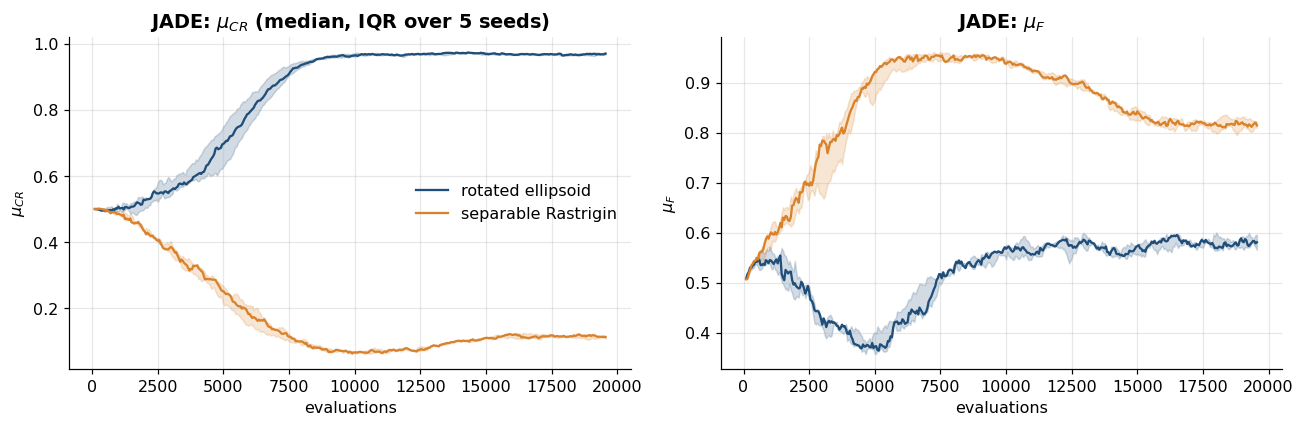

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for (tag, H), col in zip(jade_hist.items(), [PALETTE["blue"], PALETTE["orange"]]):
    ev = H[0, :, 0]
    for j, ax in zip([2, 1], axes):
        ax.plot(ev, np.median(H[:, :, j], 0), color=col, label=tag)
        ax.fill_between(ev, np.percentile(H[:, :, j], 25, 0), np.percentile(H[:, :, j], 75, 0), color=col, alpha=0.2)
axes[0].set(title=r"JADE: $\mu_{CR}$ (median, IQR over 5 seeds)", xlabel="evaluations", ylabel=r"$\mu_{CR}$")
axes[1].set(title=r"JADE: $\mu_F$", xlabel="evaluations", ylabel=r"$\mu_F$")
axes[0].legend(); plt.tight_layout(); savefig("w6_jade_adaptation.png"); plt.show()

## 2. The $(1+1)$-ES and the 1/5th success rule

The $(1+1)$-ES samples $y = x + \sigma z$, $z\sim\mathcal{N}(0,I)$, and keeps $y$ if $f(y)\le f(x)$. On the sphere
$f(x)=\Vert x\Vert^2$ at distance $R$, define the normalised step $\sigma^{\ast}=\sigma d/R$ and the normalised
progress $\varphi^{\ast}=d\,\mathbb{E}[R-R']/R$. For $d\to\infty$ (Rechenberg 1973; Beyer 2001):

$$
\varphi^{\ast}(\sigma^{\ast}) = \frac{\sigma^{\ast}}{\sqrt{2\pi}}\,e^{-\sigma^{\ast 2}/8} - \frac{\sigma^{\ast 2}}{2}\Big(1-\Phi\big(\tfrac{\sigma^{\ast}}{2}\big)\Big),
\qquad
P_s(\sigma^{\ast}) = 1-\Phi\big(\tfrac{\sigma^{\ast}}{2}\big).
$$

*Sketch.* For large $d$, $R'^2 = R^2 + 2\sigma R z_1 + \sigma^2 d$ (the other coordinates' contribution concentrates), so
$d(R-R')/R \approx -\sigma^{\ast} z_1 - \sigma^{\ast2}/2$ with $z_1\sim\mathcal{N}(0,1)$; elitism keeps only the
positive part, and integrating the Gaussian gives the formula. Success $\Leftrightarrow z_1\lt-\sigma^{\ast}/2$.

Maximising $\varphi^{\ast}$ gives $\sigma^{\ast}\approx1.224$, $\varphi^{\ast}\approx0.202$ at a success probability
$\approx0.270$; on Rechenberg's *corridor* model the optimal success probability is $\approx0.184$. **The 1/5th rule**
is the compromise: increase $\sigma$ if more than 1/5 of the mutations succeed, decrease it otherwise. We use the
smooth one-step form $\sigma\leftarrow\sigma\exp\big((\mathbb{1}_{\text{success}}-\tfrac15)/D\big)$ with damping
$D=0.8\sqrt{d+1}$ (a common implementation of the rule; the damping constant is our choice, not a canonical value). If $\sigma$ did not have to move, its stationary point would be a success rate of exactly $1/5$.
But under linear convergence $\sigma$ must *shrink* at the same rate as the distance $R$, i.e.
$\mathbb{E}[\Delta\ln\sigma]=\mathbb{E}[\Delta\ln R]\lt0$ per evaluation, and therefore the rule predicts a
realised success rate

$$
p_s = \tfrac15 + D\,\mathbb{E}[\Delta\ln R] = \tfrac15 + D\cdot\tfrac12\,\mathbb{E}[\Delta\ln f]\quad(\text{sphere}),
$$

slightly **below** $1/5$ — a prediction we can check against the measured convergence slope.

In [7]:
Phi = stats.norm.cdf
phi_star = lambda s: s / np.sqrt(2 * np.pi) * np.exp(-s**2 / 8) - s**2 / 2 * (1 - Phi(s / 2))
opt_ = minimize_scalar(lambda s: -phi_star(s), bounds=(0.1, 4), method="bounded")
s_opt, phi_opt, ps_opt = opt_.x, phi_star(opt_.x), 1 - Phi(opt_.x / 2)
print(f"optimal sigma* = {s_opt:.3f}, phi* = {phi_opt:.4f}, success probability = {ps_opt:.3f}")
check_close([s_opt, phi_opt, ps_opt], [1.224, 0.2025, 0.270], "(1+1)-ES optimum on the sphere (Rechenberg/Beyer values)", atol=2e-3)

def mc_progress(sig_star, d, n=200000, seed=0):
    """Monte Carlo of the normalised elitist progress at dimension d (x = R e_1, R = 1)."""
    r = np.random.default_rng(seed)
    z1 = r.standard_normal(n); rest = r.chisquare(d - 1, n)
    s = sig_star / d
    Rn = np.sqrt((1 + s * z1) ** 2 + s**2 * rest)
    gain = np.maximum(0.0, 1 - Rn) * d
    return gain.mean(), gain.std() / np.sqrt(n), np.mean(Rn < 1)

sig_grid = np.linspace(0.2, 3.5, 12)
mc = np.array([mc_progress(s, 2000, seed=i) for i, s in enumerate(sig_grid)])
err = np.abs(mc[:, 0] - phi_star(sig_grid))
check_true(np.all(err < 0.01), f"Monte Carlo progress at d=2000 matches the asymptotic formula (max |error| = {err.max():.4f})")

optimal sigma* = 1.224, phi* = 0.2025, success probability = 0.270
[PASS] (1+1)-ES optimum on the sphere (Rechenberg/Beyer values): got [1.224005 0.202456 0.270268], expected [1.224  0.2025 0.27  ]


[PASS] Monte Carlo progress at d=2000 matches the asymptotic formula (max |error| = 0.0016)


In [8]:
class OnePlusOneES(AskTell):
    """(1+1)-ES with the 1/5th success rule (one-step, smooth form)."""
    name = "(1+1)-ES"

    def __init__(self, d, lo, hi, budget, rng, sigma0=0.3, x0=None):
        super().__init__(d, lo, hi, budget, rng)
        self.x = (self.uniform(1)[0] if lo is not None else rng.standard_normal(d)) if x0 is None else np.array(x0, float)
        self.fx, self.sigma = None, sigma0 * self.span
        self.succ, self.hist = [], []

    def ask(self):
        if self.fx is None:
            return self.x[None]
        return self.clip(self.x + self.sigma * self.rng.standard_normal(self.d))[None]

    def tell(self, X, y):
        if self.fx is None:
            self.fx = y[0]; return
        s = y[0] <= self.fx
        if s:
            self.x, self.fx = X[0], y[0]
        self.sigma *= np.exp((s - 0.2) / (0.8 * np.sqrt(self.d + 1)))
        self.succ.append(s); self.hist.append((self.fx, self.sigma, np.linalg.norm(self.x)))

es = OnePlusOneES(d, None, None, 4000, np.random.default_rng(3), sigma0=1.0, x0=np.full(d, 3.0))
optimize(es, sphere, 4000)
Hes = np.array(es.hist)
k = np.arange(len(Hes))
sl, ic, rv, *_ = stats.linregress(k[500:], np.log(Hes[500:, 0]))
succ_rate = np.mean(es.succ[500:])
sigstar = Hes[500:, 1] * d / Hes[500:, 2]
print(f"(1+1)-ES on sphere d=10: success rate {succ_rate:.3f}, log f slope per evaluation {sl:.4f} "
      f"(d * slope / 2 = {-d * sl / 2:.3f} vs asymptotic optimum phi* = {phi_opt:.3f}), median sigma* = {np.median(sigstar):.2f}")
D_damp = 0.8 * np.sqrt(d + 1)
se_ps = np.sqrt(succ_rate * (1 - succ_rate) / len(es.succ[500:]))
check_close(succ_rate, 0.2 + D_damp * sl / 2, f"success rate predicted from the measured convergence slope (tol 4 SE = {4 * se_ps:.3f})",
            atol=4 * se_ps, rtol=0)
check_true(0.2 - succ_rate > 4 * se_ps, "the realised success rate is significantly below 1/5, as the stationarity argument predicts")
check_true(rv**2 > 0.99, f"linear convergence: R^2 of log f vs evaluations = {rv**2:.4f}")

(1+1)-ES on sphere d=10: success rate 0.156, log f slope per evaluation -0.0326 (d * slope / 2 = 0.163 vs asymptotic optimum phi* = 0.202), median sigma* = 2.41
[PASS] success rate predicted from the measured convergence slope (tol 4 SE = 0.025): got 0.15633, expected 0.156802
[PASS] the realised success rate is significantly below 1/5, as the stationarity argument predicts
[PASS] linear convergence: R^2 of log f vs evaluations = 0.9990


At $d=10$ the normalised rate $-d\cdot\text{slope}/2$ is below the $d\to\infty$ optimum $\varphi^{\ast}\approx0.202$ —
as expected, since the 1/5th rule targets a success rate below the sphere-optimal $0.27$ and finite $d$ lowers
progress. The key qualitative prediction — **linear convergence** with a step size proportional to the distance
($\sigma^{\ast}$ stationary) — holds.

## 3. CMA-ES: derivation of the update equations

CMA-ES samples $x_k = m + \sigma y_k$, $y_k\sim\mathcal{N}(0,C)$, $k=1..\lambda$, and updates
$(m,\sigma,C)$ from the $\mu$ best (Hansen & Ostermeier 2001; Hansen 2016, arXiv:1604.00772). Defaults for dimension $n$:
$\lambda = 4+\lfloor3\ln n\rfloor$, $\mu=\lfloor\lambda/2\rfloor$, $w_i\propto\ln\frac{\lambda+1}{2}-\ln i$,
$\mu_{\text{eff}}=1/\sum w_i^2$.

1. **Weighted recombination** — $y_w=\sum_{i=1}^{\mu}w_i\,y_{i:\lambda}$, $m\leftarrow m+\sigma y_w$.
2. **Cumulative step-size adaptation (CSA)** — an evolution path in the *whitened* space,
   $p_\sigma\leftarrow(1-c_\sigma)p_\sigma+\sqrt{c_\sigma(2-c_\sigma)\mu_{\text{eff}}}\;C^{-1/2}y_w$. Under random selection
   $p_\sigma\sim\mathcal{N}(0,I)$, so $\sigma\leftarrow\sigma\exp\!\big(\tfrac{c_\sigma}{d_\sigma}(\Vert p_\sigma\Vert/\mathbb{E}\Vert\mathcal{N}(0,I)\Vert-1)\big)$
   increases $\sigma$ when consecutive steps are correlated (path too long) and decreases it when they cancel.
3. **Rank-one update** — a second path $p_c\leftarrow(1-c_c)p_c+h_\sigma\sqrt{c_c(2-c_c)\mu_{\text{eff}}}\,y_w$ captures the
   sign information of consecutive steps; $c_1 p_cp_c^{\top}$ increases variance along it.
4. **Rank-$\mu$ update** — $c_\mu\sum_i w_i y_{i:\lambda}y_{i:\lambda}^{\top}$ is the maximum-likelihood estimate of the
   covariance of *selected steps*; with the rank-one term,

$$
C \leftarrow (1-c_1-c_\mu+c_1\delta(h_\sigma))\,C + c_1\,p_cp_c^{\top} + c_\mu\sum_{i=1}^{\mu}w_i\,y_{i:\lambda}y_{i:\lambda}^{\top}.
$$

with $c_1=2/((n+1.3)^2+\mu_{\text{eff}})$, $c_\mu=\min\big(1-c_1,\,2(\mu_{\text{eff}}-2+1/\mu_{\text{eff}})/((n+2)^2+\mu_{\text{eff}})\big)$,
$c_\sigma=(\mu_{\text{eff}}+2)/(n+\mu_{\text{eff}}+5)$, $d_\sigma=1+2\max(0,\sqrt{(\mu_{\text{eff}}-1)/(n+1)}-1)+c_\sigma$,
$c_c=(4+\mu_{\text{eff}}/n)/(n+4+2\mu_{\text{eff}}/n)$; $h_\sigma$ stalls $p_c$ when $\Vert p_\sigma\Vert$ is large.
The rank-$\mu$ update is a natural-gradient step on the expected fitness in the space of Gaussians (Akimoto et al.
2010; information-geometric optimisation, Ollivier et al. 2017).

**Predictions.** (a) On a convex quadratic $f(x)=\tfrac12x^{\top}Hx$, the stationary $C$ is proportional to $H^{-1}$:
the search distribution learns the level-set shape. (b) All updates depend on $f$ only through ranks and on $x$ only
through $y_i$ and $C$, so the algorithm is invariant to strictly monotone transforms of $f$ and to rotations of the
search space (given a correspondingly transformed initial state). (c) On the sphere it converges linearly.

The implementation is the `CMAES` class above (≈ 40 lines). We now test (a)–(c). For (b) the tests are *exact*: we
feed a rotated copy of the algorithm the rotated images of the original's samples and require its state to remain
the rotated image of the original's state to rounding error, and we run the same seed on $f$ and on $f^3$ and require
bit-identical trajectories. Only then do we look at the (statistical) consequence, equal runtime distributions.

In [9]:
def run_cma(f, d, budget, seed, m0, sigma0=1.0, target=None):
    cma = CMAES(d, None, None, budget, np.random.default_rng(seed), m0=m0, sigma0=sigma0)
    hit = [None]
    def cb(opt, X, y, obj):
        if target is not None and hit[0] is None and obj.best_f <= target:
            hit[0] = obj.evals
    obj = optimize(cma, f, budget, callback=cb)
    return cma, obj, hit[0]

# (a) covariance vs inverse Hessian on a rotated ellipsoid, condition number 1e6
cond = 1e6
Rot = random_rotation(d, np.random.default_rng(20))
Hdiag = 2 * cond ** (np.arange(d) / (d - 1))
Hess = Rot.T @ np.diag(Hdiag) @ Rot
f_rot_ell = shifted_rotated(lambda X: ellipsoid(X, cond), np.zeros(d), Rot)
cma, obj, _ = run_cma(f_rot_ell, d, 12000, 0, m0=Rot.T @ np.full(d, 3.0))
ev_CH = np.sort(np.linalg.eigvals(cma.C @ Hess).real)
print(f"final f = {obj.best_f:.1e}; condition number of H = {cond:.0e}, of C = {np.linalg.cond(cma.C):.2e}, of C·H = {ev_CH[-1] / ev_CH[0]:.2f}")
check_true(ev_CH[-1] / ev_CH[0] < 10, "CMA-ES: C is proportional to H^{-1} (cond(C H) < 10 while cond(H) = 1e6)")
cos_align = np.abs(np.sum(np.linalg.eigh(cma.C)[1][:, 0] * Rot.T[:, -1]))
check_true(cos_align > 0.99, f"largest-curvature direction of H = smallest-variance direction of C (|cos| = {cos_align:.4f})")

final f = 4.4e-48; condition number of H = 1e+06, of C = 1.18e+06, of C·H = 3.17
[PASS] CMA-ES: C is proportional to H^{-1} (cond(C H) < 10 while cond(H) = 1e6)
[PASS] largest-curvature direction of H = smallest-variance direction of C (|cos| = 0.9999)


In [10]:
# (b) invariances. First two EXACT tests, then a statistical one.
import copy
cond_b, target_b, seeds_b = 1e4, 1e-8, 20
f_ax = lambda X: ellipsoid(X, cond_b)
f_rt = shifted_rotated(f_ax, np.zeros(d), Rot)       # f_rt(x') = f_ax(Rot x'), i.e. x' = Q x with Q = Rot^T
x0 = np.full(d, 3.0)
Q = Rot.T

# (b1) rotation equivariance of the update equations: start from an anisotropic state (30 generations on f_ax),
# build the rotated state (Q m, sigma, Q C Q^T, Q p_sigma, Q p_c), feed the rotated copy the rotated samples Q x_k
# (evaluated on f_rt) and check that it stays the rotated image of the original, generation after generation.
cma_a = CMAES(d, None, None, 10**6, np.random.default_rng(7), m0=x0, sigma0=1.0)
for _ in range(30):
    X = cma_a.ask(); cma_a.tell(X, f_ax(X))
cma_b = copy.deepcopy(cma_a)
cma_b.m, cma_b.ps, cma_b.pc, cma_b.C = Q @ cma_a.m, Q @ cma_a.ps, Q @ cma_a.pc, Q @ cma_a.C @ Q.T
ev_b, cma_b.B = np.linalg.eigh(cma_b.C); cma_b.D = np.sqrt(ev_b)
dev = []
for _ in range(80):
    X = cma_a.ask(); Xq = X @ Q.T
    cma_a.tell(X, f_ax(X)); cma_b.tell(Xq, f_rt(Xq))
    dev.append(max(np.linalg.norm(cma_b.m - Q @ cma_a.m) / cma_a.sigma, abs(cma_b.sigma / cma_a.sigma - 1),
                   np.linalg.norm(cma_b.C - Q @ cma_a.C @ Q.T) / np.linalg.norm(cma_a.C)))
print(f"rotated copy vs rotated original over 80 generations: max relative deviation {max(dev):.1e} "
      f"(cond(C) at the end {np.linalg.cond(cma_a.C):.0f})")
check_true(max(dev) < 1e-8, "CMA-ES update is rotation equivariant: (m, sigma, C) of the rotated run = rotated image, to 1e-8")

# (b2) invariance to strictly increasing transformations of f: same seed, f vs f^3 -> identical trajectory
def cma_final_state(g, budget=3000, seed=3):
    c = CMAES(d, None, None, budget, np.random.default_rng(seed), m0=x0, sigma0=1.0)
    optimize(c, g, budget)
    return c
runs_g = [cma_final_state(g) for g in (f_ax, lambda X: f_ax(X) ** 3)]
check_true(np.array_equal(runs_g[0].m, runs_g[1].m) and runs_g[0].sigma == runs_g[1].sigma,
           "CMA-ES on f and on f^3 (same seed): bit-identical mean and step size after 3000 evaluations")

# (b3) statistical: runtimes to f <= 1e-8 on the axis-parallel vs the rotated ellipsoid (independent seeds)
rt_axis = np.array([run_cma(f_ax, d, 6000, s, m0=x0, target=target_b)[2] for s in range(seeds_b)], float)
rt_rot = np.array([run_cma(f_rt, d, 6000, s + 1000, m0=Rot.T @ x0, target=target_b)[2] for s in range(seeds_b)], float)
check_true(np.all(np.isfinite(rt_axis)) and np.all(np.isfinite(rt_rot)), "every run reached f <= 1e-8 within 6000 evaluations")
p_inv = stats.mannwhitneyu(rt_axis, rt_rot).pvalue
print(f"CMA-ES evals to 1e-8: axis-parallel median {np.median(rt_axis):.0f} [IQR {np.percentile(rt_axis, 25):.0f}-{np.percentile(rt_axis, 75):.0f}], "
      f"rotated median {np.median(rt_rot):.0f} [IQR {np.percentile(rt_rot, 25):.0f}-{np.percentile(rt_rot, 75):.0f}], Mann-Whitney p = {p_inv:.2f}")
se_ratio = 1.2533 * np.sqrt((stats.iqr(rt_axis) / 1.349) ** 2 + (stats.iqr(rt_rot) / 1.349) ** 2) / np.sqrt(seeds_b) / np.median(rt_axis)
check_true(p_inv > 0.01 and abs(np.median(rt_rot) / np.median(rt_axis) - 1) < 5 * se_ratio,
           f"CMA-ES: no detectable effect of rotation (Mann-Whitney p > 0.01; median ratio {np.median(rt_rot) / np.median(rt_axis):.3f} within 5 SE = {5 * se_ratio:.3f} of 1)")

# contrast: DE/rand/1/bin with small CR exploits separability and is NOT rotation invariant
de_ax = np.array([optimize(DEv(d, -5.0, 5.0, 8000, np.random.default_rng(s), CR=0.1), f_ax, 8000).best_f for s in range(10)])
de_rt = np.array([optimize(DEv(d, -5.0, 5.0, 8000, np.random.default_rng(s), CR=0.1), f_rt, 8000).best_f for s in range(10)])
p_de = stats.mannwhitneyu(de_ax, de_rt).pvalue
print(f"DE/rand/1/bin (CR=0.1), 8000 evals: axis-parallel median f {np.median(de_ax):.1e}, rotated {np.median(de_rt):.1e}, p = {p_de:.1e}")
check_true(p_de < 0.01 and np.median(de_rt) > 100 * np.median(de_ax), "DE with CR=0.1: rotation degrades performance by > 100x")

rotated copy vs rotated original over 80 generations: max relative deviation 1.0e-14 (cond(C) at the end 33)
[PASS] CMA-ES update is rotation equivariant: (m, sigma, C) of the rotated run = rotated image, to 1e-8


[PASS] CMA-ES on f and on f^3 (same seed): bit-identical mean and step size after 3000 evaluations


[PASS] every run reached f <= 1e-8 within 6000 evaluations
CMA-ES evals to 1e-8: axis-parallel median 4025 [IQR 3892-4175], rotated median 3900 [IQR 3842-3978], Mann-Whitney p = 0.06
[PASS] CMA-ES: no detectable effect of rotation (Mann-Whitney p > 0.01; median ratio 0.969 within 5 SE = 0.081 of 1)


DE/rand/1/bin (CR=0.1), 8000 evals: axis-parallel median f 8.0e-04, rotated 4.5e+02, p = 1.8e-04
[PASS] DE with CR=0.1: rotation degrades performance by > 100x


In [11]:
# (c) linear convergence on the sphere and stationarity of the normalised step size
cma = CMAES(d, None, None, 6000, np.random.default_rng(1), m0=np.full(d, 3.0), sigma0=1.0)
rec = []
# effective step size = sigma * sqrt(mean eigenvalue of C): C's overall scale is not fixed, only sigma^2 C matters
optimize(cma, sphere, 6000, callback=lambda o, X, y, ob: rec.append((ob.evals, y.min(), o.sigma * np.sqrt(np.trace(o.C) / d),
                                                                      np.linalg.norm(o.m))))
rec = np.array(rec); ok = rec[:, 1] > 0
sel = ok & (rec[:, 0] > 500)
sl_c, _, r_c, *_ = stats.linregress(rec[sel, 0], np.log(rec[sel, 1]))
sig_n = rec[sel, 2] * d / rec[sel, 3]
print(f"CMA-ES sphere d=10: log f slope {sl_c:.4f} per evaluation (normalised rate d*slope/2 = {-d * sl_c / 2:.3f}), "
      f"R^2 = {r_c**2:.4f}, sigma* median {np.median(sig_n):.2f}, IQR/median {stats.iqr(sig_n) / np.median(sig_n):.2f}")
check_true(r_c**2 > 0.99, "CMA-ES converges linearly on the sphere (R^2 > 0.99)")
check_true(stats.iqr(sig_n) / np.median(sig_n) < 0.5, "normalised effective step size is stationary (scale invariance)")

CMA-ES sphere d=10: log f slope -0.0151 per evaluation (normalised rate d*slope/2 = 0.075), R^2 = 0.9996, sigma* median 4.83, IQR/median 0.34
[PASS] CMA-ES converges linearly on the sphere (R^2 > 0.99)
[PASS] normalised effective step size is stationary (scale invariance)


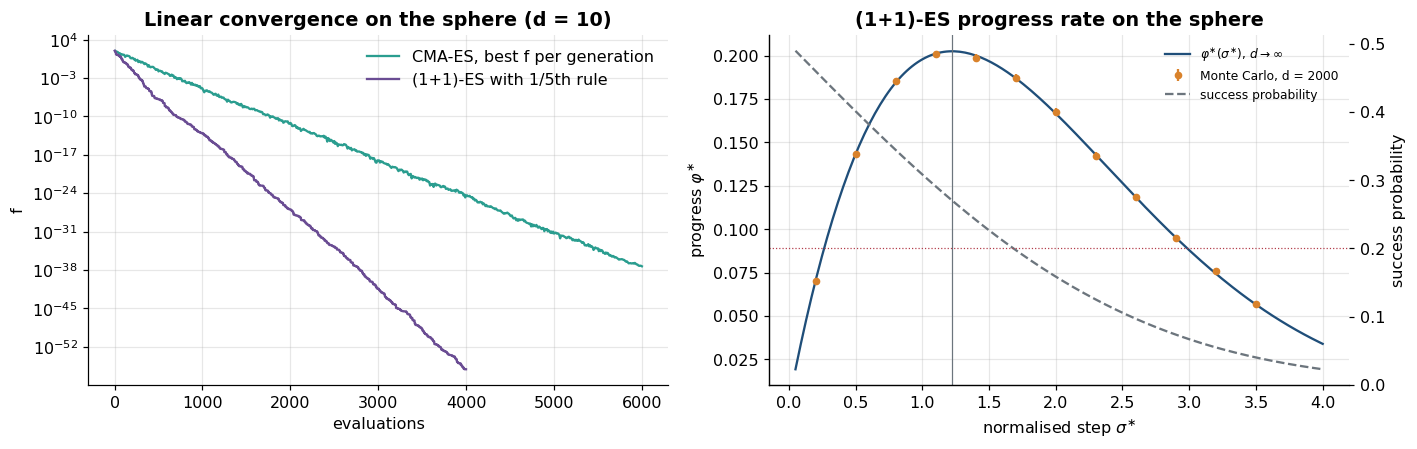

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].semilogy(rec[ok, 0], rec[ok, 1], color=PALETTE["teal"], label="CMA-ES, best f per generation")
axes[0].semilogy(np.arange(len(Hes)) + 1, Hes[:, 0], color=PALETTE["purple"], label="(1+1)-ES with 1/5th rule")
axes[0].set(title="Linear convergence on the sphere (d = 10)", xlabel="evaluations", ylabel="f")
axes[0].legend()
sg = np.linspace(0.05, 4, 200)
axes[1].plot(sg, phi_star(sg), color=PALETTE["blue"], label=r"$\varphi^{\ast}(\sigma^{\ast})$, $d\to\infty$")
axes[1].errorbar(sig_grid, mc[:, 0], yerr=2 * mc[:, 1], fmt="o", ms=4, color=PALETTE["orange"], label="Monte Carlo, d = 2000")
ax2 = axes[1].twinx(); ax2.plot(sg, 1 - Phi(sg / 2), "--", color=PALETTE["grey"], label="success probability"); ax2.grid(False)
ax2.axhline(0.2, color=PALETTE["red"], lw=0.8, ls=":"); ax2.set_ylabel("success probability")
axes[1].axvline(s_opt, color=PALETTE["grey"], lw=0.8)
axes[1].set(title="(1+1)-ES progress rate on the sphere", xlabel=r"normalised step $\sigma^{\ast}$", ylabel=r"progress $\varphi^{\ast}$")
h1, l1 = axes[1].get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels(); axes[1].legend(h1 + h2, l1 + l2, fontsize=8)
plt.tight_layout(); savefig("w6_es_convergence_progress.png"); plt.show()

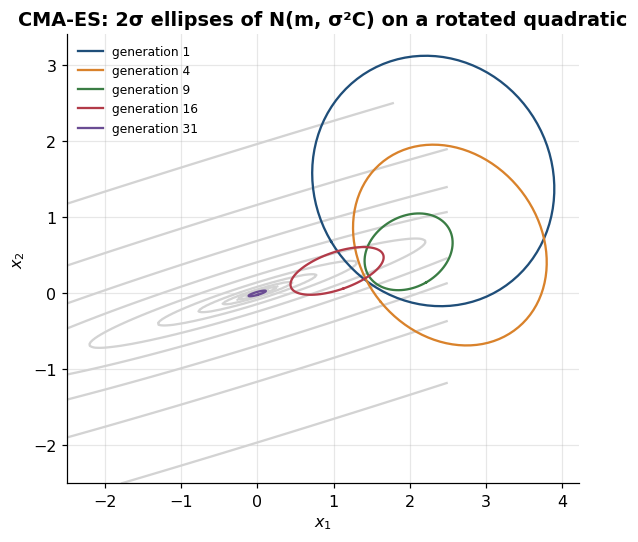

[PASS] 2-D: trace-normalised C vs trace-normalised H^{-1} after 1500 evals: got [[0.909762 0.267208]
 [0.267208 0.090238]], expected [[0.90431  0.277002]
 [0.277002 0.09569 ]]


In [13]:
# learned covariance vs inverse Hessian, visualised in 2-D
R2 = random_rotation(2, np.random.default_rng(5))
H2 = R2.T @ np.diag([2.0, 200.0]) @ R2
f2 = lambda X: 0.5 * np.einsum("ni,ij,nj->n", np.atleast_2d(X), H2, np.atleast_2d(X))
cma2 = CMAES(2, None, None, 1500, np.random.default_rng(2), m0=[2.0, 2.0], sigma0=1.0)
snaps = []
optimize(cma2, f2, 1500, callback=lambda o, X, y, ob: snaps.append((o.m.copy(), o.sigma, o.C.copy())))
fig, ax = plt.subplots(figsize=(6, 5.5))
g = np.linspace(-2.5, 2.5, 200); GX, GY = np.meshgrid(g, g)
ax.contour(GX, GY, f2(np.c_[GX.ravel(), GY.ravel()]).reshape(GX.shape), levels=np.logspace(-2, 3, 12), colors="lightgrey")
t_ = np.linspace(0, 2 * np.pi, 100)
for gen in [0, 3, 8, 15, 30]:
    m_, s_, C_ = snaps[gen]
    ev_, B_ = np.linalg.eigh(C_)
    ell = m_[:, None] + 2 * s_ * B_ @ (np.sqrt(ev_)[:, None] * np.vstack([np.cos(t_), np.sin(t_)]))
    ax.plot(*ell, label=f"generation {gen + 1}")
C_end = snaps[-1][2] / np.trace(snaps[-1][2]); Hinv = np.linalg.inv(H2) / np.trace(np.linalg.inv(H2))
ax.set(title="CMA-ES: 2σ ellipses of N(m, σ²C) on a rotated quadratic", xlabel="$x_1$", ylabel="$x_2$", aspect="equal")
ax.legend(fontsize=8); savefig("w6_cma_ellipses.png"); plt.show()
check_close(C_end, Hinv, "2-D: trace-normalised C vs trace-normalised H^{-1} after 1500 evals", atol=0.02)

## 4. DE and CMA-ES vs the five core algorithms at equal budgets

Protocol: four shifted **and rotated** functions in $d=10$ (random shift in 60 % of the box, Haar rotation), budget
5000 evaluations ($500d$), 5 seeds, box constraints handled by clipping for every algorithm. Reported: median and IQR
of the final error $f-f^{\ast}$. (The lab of this week does this properly with fixed-target views and statistics; here
the aim is a first impression.)

In [14]:
algs = [SA, TS, GA, PSO, ACOR, DE, JADE, OnePlusOneES, CMAES]
fnames = ["ellipsoid", "rosenbrock", "rastrigin", "ackley"]
B_cmp, seeds_cmp = 5000, 5
grid = np.unique(np.geomspace(10, B_cmp, 40).astype(int))
comp, curves = {}, {}
from utils import best_so_far_on_grid
for fn in fnames:
    b = BENCHMARKS[fn]
    rr = np.random.default_rng(100 + len(fn))
    fsr = shifted_rotated(b.f, rr.uniform(0.6 * b.lower, 0.6 * b.upper, d) if fn != "rosenbrock" else rr.uniform(-2, 2, d) - 1,
                          random_rotation(d, rr))
    for A in algs:
        res, cv = [], []
        for s in range(seeds_cmp):
            obj = optimize(A(d, b.lower, b.upper, B_cmp, np.random.default_rng(s)), fsr, B_cmp)
            res.append(obj.best_f); cv.append(best_so_far_on_grid(*obj.trace(), grid))
        comp[fn, A.name], curves[fn, A.name] = np.array(res), np.array(cv)
names = [A.name for A in algs]
print(f"{'':12s}" + "".join(f"{n:>13s}" for n in names))
for fn in fnames:
    print(f"{fn:12s}" + "".join(f"{np.median(comp[fn, n]):13.2e}" for n in names))
mean_rank = np.mean([stats.rankdata([np.median(comp[fn, n]) for n in names]) for fn in fnames], 0)
print("mean rank of the median:", dict(zip(names, np.round(mean_rank, 2).tolist())))
check_true(names[np.argmin(mean_rank)] == "CMA-ES", "CMA-ES has the best mean rank across the four shifted-rotated functions")

                       SA           TS           GA          PSO        ACO_R           DE         JADE     (1+1)-ES       CMA-ES
ellipsoid        1.57e+04     1.50e+03     6.51e+03     3.81e+03     5.92e+03     5.55e+02     8.82e+02     9.25e+02     4.64e-02
rosenbrock       1.47e+03     6.55e+00     5.80e+01     1.88e+02     6.70e+00     9.99e+00     7.65e+00     4.07e+00     8.49e-02
rastrigin        6.96e+01     7.86e+01     1.92e+01     1.92e+01     3.75e+01     5.20e+01     4.20e+01     5.71e+01     2.09e+01
ackley           1.98e+01     1.96e+01     2.53e+00     1.36e-02     3.04e-07     1.57e+00     1.88e-01     1.98e+01     7.55e-15
mean rank of the median: {'SA': 8.75, 'TS': 6.0, 'GA': 5.75, 'PSO': 4.5, 'ACO_R': 4.25, 'DE': 4.75, 'JADE': 4.25, '(1+1)-ES': 5.25, 'CMA-ES': 1.5}
[PASS] CMA-ES has the best mean rank across the four shifted-rotated functions


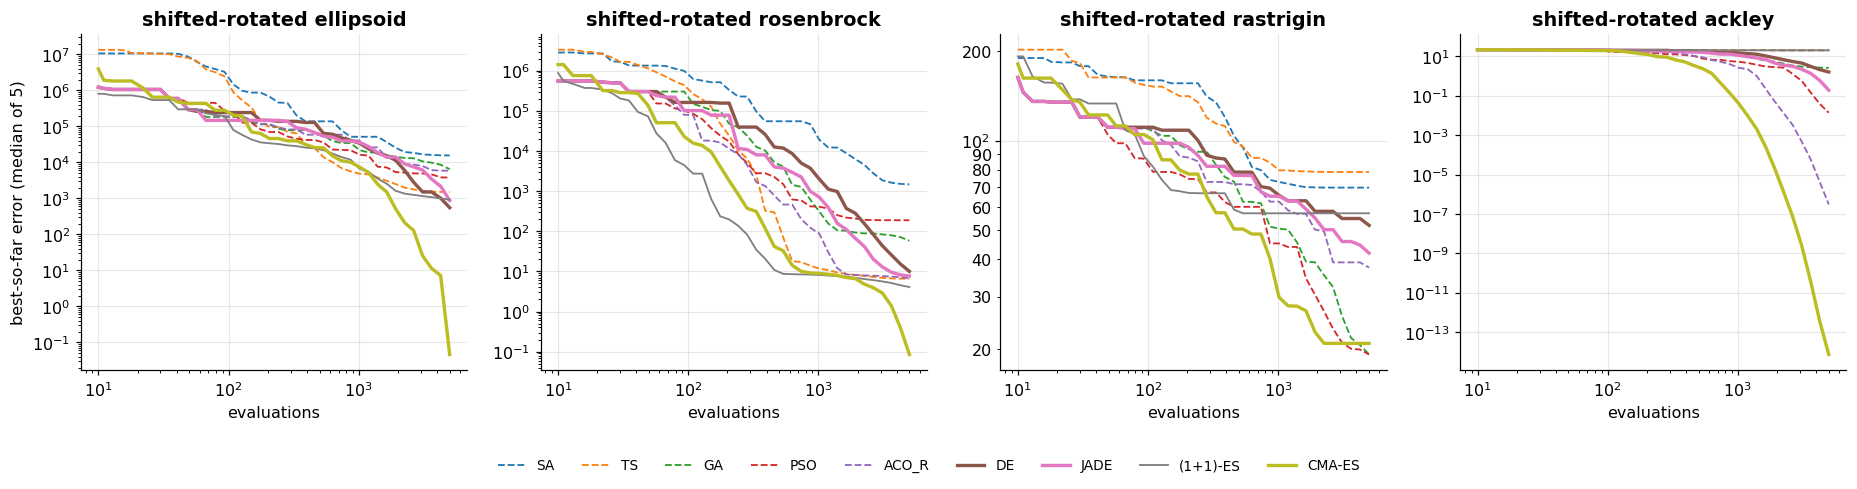

In [15]:
from matplotlib.ticker import FormatStrFormatter
fig, axes = plt.subplots(1, 4, figsize=(17, 4.3))
colors = dict(zip(names, plt.get_cmap("tab10").colors))       # nine distinct colours, one per algorithm
for ax, fn in zip(axes, fnames):
    for n in names:
        c = curves[fn, n]
        ax.plot(grid, np.median(c, 0), color=colors[n], lw=2.2 if n in ("CMA-ES", "JADE", "DE") else 1.2,
                ls="-" if n in ("CMA-ES", "JADE", "DE", "(1+1)-ES") else "--", label=n)
    ax.set(xscale="log", yscale="log", title=f"shifted-rotated {fn}", xlabel="evaluations")
    lo_, hi_ = ax.get_ylim()
    if hi_ / lo_ < 100:                                         # less than two decades: label the minor ticks too
        ax.yaxis.set_minor_formatter(FormatStrFormatter("%g"))
axes[0].set_ylabel("best-so-far error (median of 5)")
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=9, fontsize=9, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout(rect=(0, 0.06, 1, 1)); savefig("w6_de_cma_vs_core.png"); plt.show()

**Interpretation.** CMA-ES, which learns a full metric, is orders of magnitude ahead of everything else on the
ill-conditioned rotated ellipsoid and on Rosenbrock. DE's difference vectors adapt the step *scale* and partly the
orientation to the population, which puts DE and JADE in the next group on the ellipsoid; SA and TS, whose isotropic
steps follow a fixed schedule, are limited by the largest curvature. On multimodal Rastrigin the advantage of
covariance learning disappears: a small-population CMA-ES converges into a local basin and is no better than GA or PSO
(restarts with increasing population, IPOP-CMA-ES, Auger & Hansen 2005, are the standard remedy). The exact ordering of
the middle group depends on budget and settings — do not over-read five seeds; the lab adds the statistics.

**AI/ML connection.** CMA-ES is a default sampler for continuous hyperparameters (e.g. in Optuna) and for
neuro-evolution of small policies; OpenAI-ES (Salimans et al. 2017) is a $(\mu/\mu,\lambda)$-ES with a fixed isotropic
covariance whose update is a Monte-Carlo gradient — CMA-ES's rank-$\mu$ update is the natural-gradient generalisation.

## Key takeaways
- DE's mutation is **self-scaling**: its variance obeys Zaharie's law $\mathbb{E}[\mathrm{Var}']=(2F^2p-2p/N+p^2/N+1)\mathrm{Var}$,
  (exact when $r_1$ may equal $i$; $O(p/N^2)$ different for fully distinct indices), which gives the critical $F$ below
  which variation alone collapses the population.
- JADE adapts $F$ and $CR$ from successful trials; $\mu_{CR}$ goes up on non-separable problems and down on separable ones.
- The 1/5th success rule follows from the sphere progress-rate formula (optimal $P_s\approx0.27$) and the corridor
  ($\approx0.18$); it yields linear convergence.
- CMA-ES learns $C\propto H^{-1}$ on quadratics, is rotation invariant (DE with small $CR$ is not) and converges linearly;
  covariance learning is what makes it the strongest method on ill-conditioned non-separable problems.

## Exercises
1. ★ Show that for i.i.d. population members with covariance $\Sigma$, the difference $x_{r_2}-x_{r_3}$ has covariance
   $2\Sigma$. Why does the finite-population correction $-2p/N$ appear in Zaharie's formula?
2. ★★ Derive Zaharie's variance law for DE/rand/1/bin, and the analogue for DE/best/1 (hint: $x_{\text{best}}$ is not random).
3. ★★ Derive $P_s(\sigma^{\ast})=1-\Phi(\sigma^{\ast}/2)$ and the progress-rate formula for the $(1+1)$-ES on the sphere as $d\to\infty$.
4. ★★ Prove that CMA-ES is invariant under strictly increasing transformations $g\circ f$, and under $x\mapsto Rx$ for
   orthogonal $R$ provided $m_0\mapsto Rm_0$ and $C_0\mapsto RC_0R^{\top}$.
5. ★★★ Implement active CMA-ES (negative weights for the worst $\lambda-\mu$ samples, Jastrebski & Arnold 2006) and
   measure the speed-up on the rotated ellipsoid over 10 seeds.
6. ★★★ Implement IPOP-CMA-ES (restarts with doubled $\lambda$) and compare it with JADE on the shifted-rotated Rastrigin
   at $10^4d$ evaluations, reporting median and IQR of the error.